In [14]:
from google.colab import drive

drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [15]:
from pathlib import Path

DATASET_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/split"
)

TRAIN_IMAGES = DATASET_ROOT / "images" / "train"
TRAIN_LABELS = DATASET_ROOT / "labels" / "train"

VAL_IMAGES = DATASET_ROOT / "images" / "val"
VAL_LABELS = DATASET_ROOT / "labels" / "val"

image_exts = {".jpg", ".jpeg", ".png", ".bmp"}

train_images = [
    p for p in TRAIN_IMAGES.iterdir()
    if p.suffix.lower() in image_exts
]

train_labels = list(TRAIN_LABELS.glob("*.txt"))

val_images = [
    p for p in VAL_IMAGES.iterdir()
    if p.suffix.lower() in image_exts
]

val_labels = list(VAL_LABELS.glob("*.txt"))

print("Train images:", len(train_images))
print("Train labels:", len(train_labels))
print("Val images:", len(val_images))
print("Val labels:", len(val_labels))

Train images: 73
Train labels: 73
Val images: 19
Val labels: 19


In [17]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(yaml_path),
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    device=0,
    project="/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/runs",
    name="yolov8n_board"
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n

RuntimeError: Dataset '/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/data.yaml' error ❌ '/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/data.yaml' does not exist

In [20]:
from pathlib import Path

DATASET_ROOT = Path(
    "/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/split"
)

yaml_path = DATASET_ROOT / "data.yaml"

yaml_text = f"""path: {DATASET_ROOT}
train: images/train
val: images/val

names:
  0: cube
  1: cylinder
  2: empty
"""

yaml_path.write_text(yaml_text)

print("Created:", yaml_path)
print("Exists:", yaml_path.exists())
print()
print(yaml_path.read_text())

Created: /content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/split/data.yaml
Exists: True

path: /content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/split
train: images/train
val: images/val

names:
  0: cube
  1: cylinder
  2: empty



In [21]:
print("YAML:", yaml_path, yaml_path.exists())
print("Train images:", (DATASET_ROOT / "images/train").exists())
print("Train labels:", (DATASET_ROOT / "labels/train").exists())
print("Val images:", (DATASET_ROOT / "images/val").exists())
print("Val labels:", (DATASET_ROOT / "labels/val").exists())

YAML: /content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/split/data.yaml True
Train images: True
Train labels: True
Val images: True
Val labels: True


In [22]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

results = model.train(
    data=str(yaml_path),
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    device=0,
    project="/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/runs",
    name="yolov8n_board"
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/split/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=

In [24]:
BEST_MODEL = "/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/runs/yolov8n_board-4/weights/best.pt"

In [25]:
from ultralytics import YOLO

model = YOLO(BEST_MODEL)

metrics = model.val(
    data="/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/split/data.yaml"
)

print(metrics)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.1 ms, read: 28.5±1.7 MB/s, size: 27.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/split/labels/val.cache... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 2.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.3it/s 0.9s
                   all         19        171      0.987      0.999      0.995      0.844
                  cube          7         28      0.969          1      0.995      0.893
              cylinder          9         45          1      0.996      0.995      0.831
                 empty         19      


image 1/1 /content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/split/images/val/image_004_r3_rot90.jpg: 640x480 5 cylinders, 4 emptys, 7.2ms
Speed: 1.3ms preprocess, 7.2ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 480)


array([[[159, 164, 155],
        [162, 167, 158],
        [166, 171, 162],
        ...,
        [143, 144, 142],
        [144, 145, 143],
        [145, 146, 144]],

       [[163, 168, 159],
        [166, 171, 162],
        [170, 175, 166],
        ...,
        [143, 144, 142],
        [144, 145, 143],
        [145, 146, 144]],

       [[168, 173, 164],
        [171, 176, 167],
        [176, 181, 172],
        ...,
        [141, 144, 142],
        [142, 145, 143],
        [143, 146, 144]],

       ...,

       [[138, 139, 137],
        [138, 139, 137],
        [136, 139, 137],
        ...,
        [144, 150, 145],
        [148, 154, 149],
        [151, 157, 152]],

       [[138, 139, 137],
        [138, 139, 137],
        [136, 139, 137],
        ...,
        [143, 149, 144],
        [149, 155, 150],
        [153, 159, 154]],

       [[138, 139, 137],
        [138, 139, 137],
        [136, 139, 137],
        ...,
        [143, 149, 144],
        [149, 155, 150],
        [153, 159, 154]]], dtype=uint8)
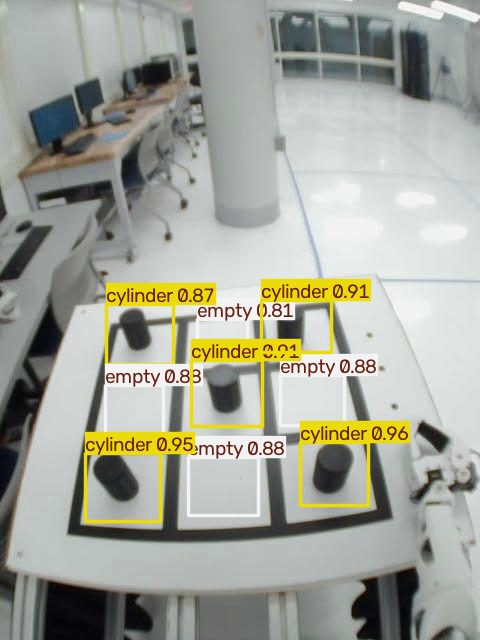

In [28]:
from pathlib import Path
import random
from IPython.display import display

VAL_FOLDER = Path(
    "/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/split/images/val"
)

val_images = list(VAL_FOLDER.glob("*"))

test_image = random.choice(val_images)

results = model.predict(
    source=str(test_image),
    conf=0.5
)

for r in results:
    display(r.plot())

In [29]:
from ultralytics import YOLO

BEST_MODEL = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "my_yolo_dataset/runs/yolov8n_board-4/weights/best.pt"
)

DATA_YAML = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "my_yolo_dataset/split/data.yaml"
)

model = YOLO(BEST_MODEL)

exported_model = model.export(
    format="litert",
    quantize=8,          # INT8 weights + INT8 activations
    data=DATA_YAML,      # calibration dataset
    imgsz=320,
    batch=1,
    device="cpu"
)

print("Exported model:")
print(exported_model)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ LiteRT INT8 export does not support end2end models, disabling end2end branch.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 2.0 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/runs/yolov8n_board-4/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 7, 2100) (6.0 MB)
LiteRT: collecting INT8 calibration images from 'data=/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/split/data.yaml'
WARNING ⚠️ val: Slow image access detected (ping: 0.5±0.1 ms, read: 26.3±3.1 MB/s, size: 28.1 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Colab 

/usr/local/lib/python3.13/dist-packages/torchao/quantization/quant_api.py:1558: SyntaxWarning: invalid escape sequence '\.'
  * regex for parameter names, must start with `re:`, e.g. `re:language\.layers\..+\.q_proj.weight`.



LiteRT: starting export with litert_torch 0.9.4...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

...

(00:00) [START] Write Model to /content/drive/MyDrive/Colab 
Notebooks/my_yolo_dataset/runs/yolov8n_board-4/weights/best_int8.tflite

(00:00) [ DONE] Write Model to /content/drive/MyDrive/Colab 
Notebooks/my_yolo_dataset/runs/yolov8n_board-4/weights/best_int8.tflite (+00:00)

LiteRT: applying static quantization (int8 weights + int8 activations)...


/usr/local/lib/python3.13/dist-packages/ai_edge_litert/interpreter.py:480: UserWarning: Warning: Enabling `experimental_preserve_all_tensors` with the BUILTIN or AUTO op resolver is intended for debugging purposes only. Be aware that this can significantly increase memory usage by storing all intermediate tensors. If you encounter memory problems or are not actively debugging, consider disabling this option.
  warnings.warn(
Applying Transformations to tensors:: 100%|██████████| 413/413 [00:00<00:00, 30568.89it/s]


Model name: /content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/runs/yolov8n_board-4/weights/best_int8.tflite
Original model size: 11.62 MiB
Quantized model size: 3.16 MiB
Quantization Ratio: 0.27 (3.7x smaller)
Total time: 147.86 ms
LiteRT: export success ✅ 24.0s, saved as '/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/runs/yolov8n_board-4/weights/best_int8.tflite' (3.2 MB)

Export complete (24.2s)
Results saved to /content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/runs/yolov8n_board-4/weights/best_int8.tflite
Predict:         yolo predict task=detect model=/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/runs/yolov8n_board-4/weights/best_int8.tflite imgsz=320 
Validate:        yolo val task=detect model=/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/runs/yolov8n_board-4/weights/best_int8.tflite imgsz=320 data=/content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/split/data.yaml  
Visualize:       https://netron.app
Exported model:
/content/drive/MyDrive

In [30]:
import numpy as np

try:
    from ai_edge_litert.interpreter import Interpreter
except ImportError:
    import tensorflow as tf
    Interpreter = tf.lite.Interpreter

TFLITE_MODEL = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "my_yolo_dataset/runs/yolov8n_board-4/weights/best_int8.tflite"
)

interpreter = Interpreter(model_path=TFLITE_MODEL)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("INPUTS")
for x in input_details:
    print("name:", x["name"])
    print("shape:", x["shape"])
    print("dtype:", x["dtype"])
    print("quantization:", x["quantization"])
    print()

print("OUTPUTS")
for x in output_details:
    print("name:", x["name"])
    print("shape:", x["shape"])
    print("dtype:", x["dtype"])
    print("quantization:", x["quantization"])
    print()

INPUTS
name: serving_default_args_0
shape: [  1   3 320 320]
dtype: <class 'numpy.float32'>
quantization: (0.0, 0)

OUTPUTS
name: serving_default_output_0_output_dequant
shape: [   1    7 2100]
dtype: <class 'numpy.float32'>
quantization: (0.0, 0)



Loading /content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/runs/yolov8n_board-4/weights/best_int8.tflite for LiteRT inference...

image 1/1 /content/drive/MyDrive/Colab Notebooks/my_yolo_dataset/split/images/val/image_005_r2_rot90.jpg: 320x320 5 cylinders, 5 emptys, 51.3ms
Speed: 3.6ms preprocess, 51.3ms inference, 14.2ms postprocess per image at shape (1, 3, 320, 320)


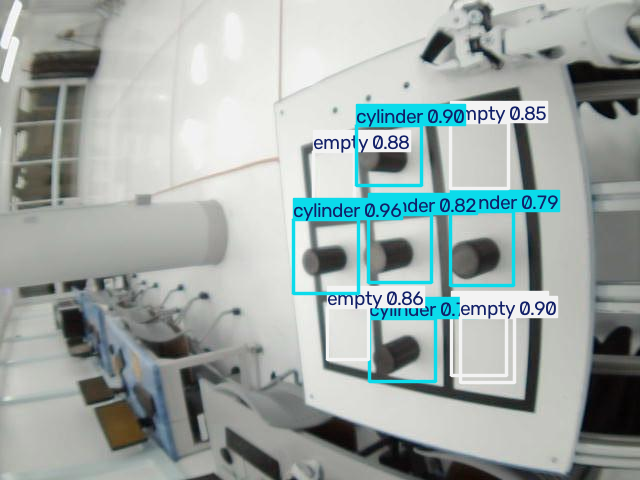

In [31]:
from ultralytics import YOLO
from pathlib import Path
import random
from PIL import Image

TFLITE_MODEL = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "my_yolo_dataset/runs/yolov8n_board-4/"
    "weights/best_int8.tflite"
)

VAL_FOLDER = Path(
    "/content/drive/MyDrive/Colab Notebooks/"
    "my_yolo_dataset/split/images/val"
)

model_tflite = YOLO(TFLITE_MODEL)

test_image = random.choice(
    list(VAL_FOLDER.glob("*"))
)

results = model_tflite.predict(
    source=str(test_image),
    conf=0.5
)

for r in results:
    annotated = r.plot()
    display(
        Image.fromarray(
            annotated[..., ::-1]
        )
    )